<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Load-Modules" data-toc-modified-id="Load-Modules-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Load Modules</a></span></li><li><span><a href="#Make-an-example" data-toc-modified-id="Make-an-example-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Make an example</a></span></li><li><span><a href="#Compute-modularity" data-toc-modified-id="Compute-modularity-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Compute modularity</a></span><ul class="toc-item"><li><span><a href="#Example-1" data-toc-modified-id="Example-1-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Example 1</a></span></li><li><span><a href="#Example-2:-0-&amp;-1-in-community" data-toc-modified-id="Example-2:-0-&amp;-1-in-community-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Example 2: 0 &amp; 1 in community</a></span></li><li><span><a href="#Example-2:-0-&amp;-2-in-community" data-toc-modified-id="Example-2:-0-&amp;-2-in-community-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Example 2: 0 &amp; 2 in community</a></span></li><li><span><a href="#Example-1-and-2-in-same-community?" data-toc-modified-id="Example-1-and-2-in-same-community?-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Example 1 and 2 in same community?</a></span></li></ul></li></ul></div>

# Modularity calculations

## Load Modules

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Make an example

In [2]:
edges = [
    (0, 1, 1.0),
    (0, 2, 0.2),
    (1, 2, 0.1),
]

G = nx.Graph()
G.add_weighted_edges_from(edges)

{(0, 1): Text(0.48047026891386446, 0.4823783500004417, '1.00'),
 (0, 2): Text(-0.4999973166278453, -0.15895588174269015, '0.20'),
 (1, 2): Text(0.019529662501070355, -0.3234181299005048, '0.10')}

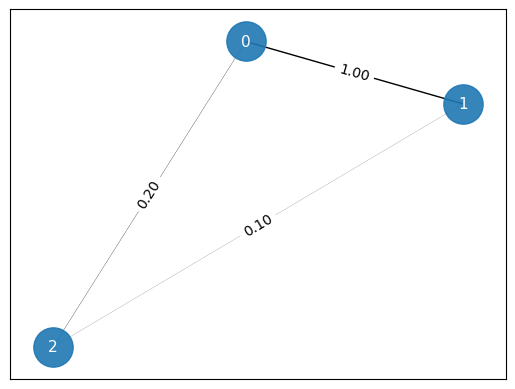

In [3]:
pos = nx.spring_layout(G, seed=42)

weights = nx.get_edge_attributes(G, "weight")
edge_widths = [weights[(u, v)] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths)
nx.draw_networkx_labels(G, pos, font_size=11, font_color="white")

# Draw edge labels (weights)
edge_labels = {e: f"{w:.2f}" for e, w in weights.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

## Compute modularity

In [4]:
N = G.number_of_nodes()
m = G.number_of_edges()

Adj matrix

In [5]:
A = nx.to_numpy_array(G, weight="weight")
print(A)

[[0.  1.  0.2]
 [1.  0.  0.1]
 [0.2 0.1 0. ]]


Weight sum

In [6]:
k = A.sum(axis=1)
print(k)

[1.2 1.1 0.3]


### Example 1

Compute modularity (no communities). $\delta$ is the identity matrix

In [7]:
delta = np.identity(N) 

In [8]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M}")

Modularity is -0.07611111111111112


### Example 2: 0 & 1 in community

In [18]:
delta = np.identity(N) 
delta[0,1]=1
delta[1,0]=1
print(delta)

[[1. 1. 0.]
 [1. 1. 0.]
 [0. 0. 1.]]


In [19]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M}")

Modularity is 0.1838888888888889


### Example 2: 0 & 2 in community

In [12]:
delta = np.identity(N) 
delta[np.ix_([0, 2], [0, 2])] = 1
print(delta)

[[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 1.]]


In [13]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M}")

Modularity is -0.02944444444444444


### Example 1 and 2 in same community?

In [14]:
delta = np.identity(N) 
delta[np.ix_([1, 2], [1, 2])] = 1
print(delta)

[[1. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]]


In [15]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M}")

Modularity is -0.061111111111111116


In [16]:
(A*delta).sum()/(2*m) - (A.sum()/(2*m))**2

np.float64(-0.15444444444444447)